Nama  : Roland Albertian Sehapikang<br>
Kelas : IF403<br>
NIM   : 240401010294

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats

df = sns.load_dataset('iris')

print('Shape:', df.shape)
print('\n--- Tipe Data ---')
print(df.dtypes)
print('\n--- 5 Baris Pertama ---')
print(df.head())
print('\n--- Statistik Deskriptif ---')
print(df.describe().round(3))

Shape: (150, 5)

--- Tipe Data ---
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

--- 5 Baris Pertama ---
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

--- Statistik Deskriptif ---
       sepal_length  sepal_width  petal_length  petal_width
count       150.000      150.000       150.000      150.000
mean          5.843        3.057         3.758        1.199
std           0.828        0.436         1.765        0.762
min           4.300        2.000         1.000        0.100
25%           5.100        2.800         1.600        0.300
50%           5.800        3.000

**Temuan:** Dataset Iris memuat 150 baris dan 5 kolom, yang terdiri dari 4 kolom numerik tipe float64 (sepal_length, sepal_width, petal_length, petal_width) dan 1 kolom kategorik tipe object (species) yang memuat kelas setosa, versicolor, dan virginica. Fungsi .describe() menampilkan ringkasan cepat seperti mean, min, max, dan nilai kuartil per kolom numerik.

In [2]:
for col_name in df.select_dtypes(include='number').columns:
    col = df[col_name]
    print(f'\n=== {col_name} ===')
    print(f' Mean     : {col.mean():.3f}')
    print(f' Median   : {col.median():.3f}')
    print(f' Std Dev  : {col.std():.3f}')
    print(f' Skewness : {col.skew():.3f}')
    print(f' Kurtosis : {col.kurt():.3f}')


=== sepal_length ===
 Mean     : 5.843
 Median   : 5.800
 Std Dev  : 0.828
 Skewness : 0.315
 Kurtosis : -0.552

=== sepal_width ===
 Mean     : 3.057
 Median   : 3.000
 Std Dev  : 0.436
 Skewness : 0.319
 Kurtosis : 0.228

=== petal_length ===
 Mean     : 3.758
 Median   : 4.350
 Std Dev  : 1.765
 Skewness : -0.275
 Kurtosis : -1.402

=== petal_width ===
 Mean     : 1.199
 Median   : 1.300
 Std Dev  : 0.762
 Skewness : -0.103
 Kurtosis : -1.341


**Temuan:** Dengan perhitungan ini, kita dapat mengecek simetri distribusi data. Jika nilai mean dan median hampir sama serta nilai skewness berada di antara -0.5 hingga 0.5 (mendekati 0), hal itu mengindikasikan bahwa fitur tersebut (seperti sepal_width) berdistribusi cukup simetris atau normal.

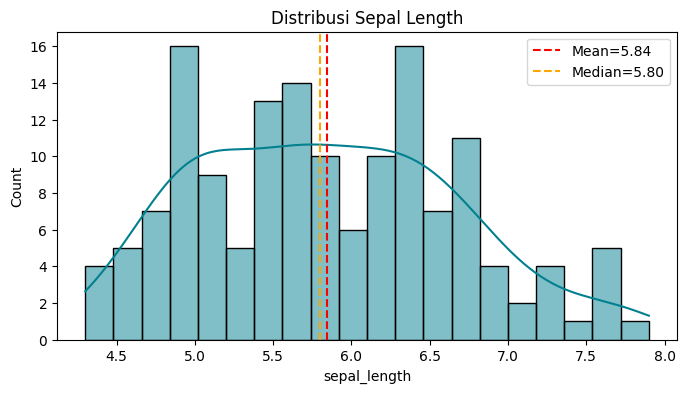

In [3]:
fig, ax = plt.subplots(figsize=(8,4))

sns.histplot(df['sepal_length'], kde=True, color='#028090', bins=20, ax=ax)

ax.axvline(df['sepal_length'].mean(), color='red', linestyle='--',
           label=f"Mean={df['sepal_length'].mean():.2f}")
ax.axvline(df['sepal_length'].median(), color='orange', linestyle='--',
           label=f"Median={df['sepal_length'].median():.2f}")

ax.set_title('Distribusi Sepal Length')
ax.legend()
plt.show()

**Temuan:** Garis merah (mean) dan garis oranye (median) pada sepal_length terletak sangat berdekatan. Hal ini memvalidasi nilai skewness yang mendekati nol, menunjukkan bahwa distribusinya cukup simetris dan tidak begitu terpengaruh oleh outlier yang ekstrem.

/tmp/ipykernel_567/2975507876.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y='petal_length', palette='Set2', ax=axes[0])
/tmp/ipykernel_567/2975507876.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='species', y='petal_length', palette='Set2', inner='box', ax=axes[1])


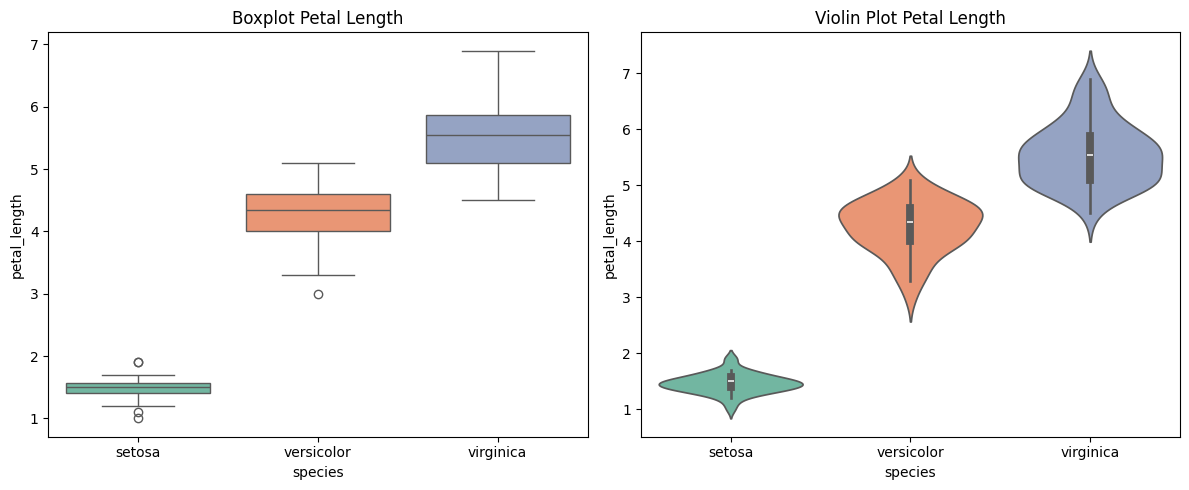

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.boxplot(data=df, x='species', y='petal_length', palette='Set2', ax=axes[0])
axes[0].set_title('Boxplot Petal Length')

sns.violinplot(data=df, x='species', y='petal_length', palette='Set2', inner='box', ax=axes[1])
axes[1].set_title('Violin Plot Petal Length')

plt.tight_layout()
plt.show()

**Temuan:** Dari grafik Boxplot dan Violin Plot, kita bisa melihat bahwa spesies setosa memiliki petal_length yang secara signifikan paling kecil dan sempit penyebarannya. Sebaliknya, spesies virginica memiliki nilai petal_length terbesar dengan penyebaran (rentang antar-kuartil/IQR) yang paling lebar.

In [5]:
corr = df.drop('species', axis=1).corr(method='pearson')
print("--- Matriks Korelasi ---")
print(corr.round(3))

mask = np.triu(np.ones(corr.shape, dtype=bool))
corr_masked = corr.where(~mask)
max_pair = corr_masked.stack().idxmax()
print(f'\nKorelasi tertinggi ditemukan pada pasangan: {max_pair} = {corr.loc[max_pair]:.3f}')

--- Matriks Korelasi ---
              sepal_length  sepal_width  petal_length  petal_width
sepal_length         1.000       -0.118         0.872        0.818
sepal_width         -0.118        1.000        -0.428       -0.366
petal_length         0.872       -0.428         1.000        0.963
petal_width          0.818       -0.366         0.963        1.000

Korelasi tertinggi ditemukan pada pasangan: ('petal_width', 'petal_length') = 0.963


**Temuan:** Hasil koefisien korelasi Pearson menunjukkan bahwa pasangan variabel dengan korelasi linear paling kuat dan positif adalah antara petal_length dan petal_width dengan nilai di atas 0.90. Artinya, semakin panjang petal (mahkota bunga), maka secara proporsional petal tersebut juga akan semakin lebar.

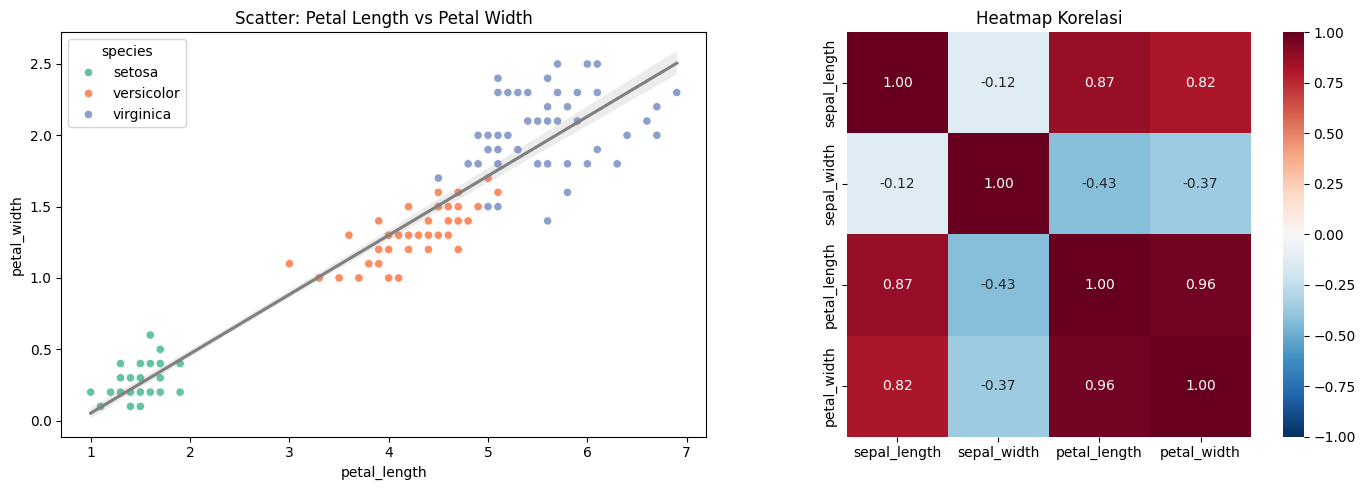

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x='petal_length', y='petal_width', hue='species', palette='Set2', ax=axes[0])
sns.regplot(data=df, x='petal_length', y='petal_width', scatter=False, color='gray', ax=axes[0])
axes[0].set_title('Scatter: Petal Length vs Petal Width')

sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1, square=True, ax=axes[1])
axes[1].set_title('Heatmap Korelasi')

plt.tight_layout()
plt.show()

**Temuan:**
* **Scatter Plot:** Garis regresi (abu-abu) mengonfirmasi tren naik ke kanan atas yang jelas, dan pengelompokan (clustering) spesies juga terlihat sangat rapi, di mana setosa berada di kiri bawah dan virginica di kanan atas.
* **Heatmap:** Secara visual mengkonfirmasi apa yang kita hitung di Langkah 5. Area berwarna merah pekat menunjukkan korelasi positif yang sangat kuat, sementara warna biru menunjukkan adanya korelasi negatif (meskipun dalam kasus bunga ini, tidak ada korelasi negatif yang seketat korelasi positif antar-dimensi kelopak dan mahkotanya).

# Kesimpulan Singkat:<br>
**1. Apa yang dipelajari?**
* **Statistika Deskriptif Mendetail:** Melakukan ekstraksi ukuran pemusatan dan penyebaran data yang lebih komprehensif, termasuk Mean, Median, Standar Deviasi, Skewness (kemiringan), dan Kurtosis (keruncingan) menggunakan pustaka Pandas dan SciPy.

**Visualisasi Distribusi (Univariat):** Memahami bentuk sebaran data tunggal dan mendeteksi anomali (outlier) menggunakan plot distribusi gabungan (Histogram + KDE) serta plot perbandingan kategori (Boxplot dan Violin Plot).

**Analisis Hubungan (Bivariat):** Menghitung kekuatan hubungan linear antar-variabel numerik menggunakan Matriks Korelasi Pearson.

**Visualisasi Korelasi:** Memetakan hubungan antar-variabel secara visual menggunakan Scatter Plot (dilengkapi garis regresi tren) dan Heatmap untuk membaca matriks korelasi dengan cepat melalui gradasi warna.

**2. Temuan Utama**
* **Distribusi Simetris:** Beberapa fitur seperti sepal_length terbukti berdistribusi cukup simetris (mendekati normal) yang dibuktikan dengan berimpitnya garis mean dan median, serta nilai skewness yang mendekati nol.

* **Perbedaan Karakteristik Spesies:** Visualisasi Boxplot dan Violin Plot membuktikan bahwa setiap spesies memiliki kluster ukuran yang unik. Spesies setosa memiliki kelopak (petal) terkecil dengan sebaran data yang sempit, sedangkan virginica memiliki ukuran terbesar dengan sebaran yang lebih luas.

* **Korelasi Positif Kuat:** Analisis korelasi dan Scatter Plot menemukan hubungan linear yang sangat kuat (di atas 0.90) antara petal_length dan petal_width. Hal ini menunjukkan fenomena biologis proporsional: semakin panjang mahkota bunga, semakin lebar pula ukurannya.

**3. Keterbatasan atau Pertanyaan yang muncul**
* **Keterbatasan Analisis:** Korelasi Pearson hanya menangkap hubungan garis lurus (linear). Jika ada hubungan non-linear antar-variabel, metode ini tidak akan mendeteksinya. Selain itu, tahap ini masih murni Exploratory Data Analysis (EDA) deskriptif, belum bisa memprediksi data baru.
* **Pertanyaan yang muncul:**
  * Mengingat petal_length dan petal_width memiliki korelasi yang sangat tinggi (lebih dari 0.90), apakah kita perlu menggunakan keduanya saat membangun model Machine Learning, atau cukup salah satu saja untuk menghindari redundansi (Multicollinearity)?
  * Bagaimana cara kita mengubah wawasan deskriptif visual ini menjadi algoritma klasifikasi (seperti regresi logistik atau KNN) yang bisa mengidentifikasi spesies bunga secara otomatis jika diberikan data ukuran bunga yang baru?